# Pairs Plots of Simulated Data

Two variables have one joint distribution, so `.plot()` just draws it. Three or more have
no single "the plot" -- there are three pairs among three variables, six among four -- so
`.plot(pairs=True)` draws a **matrix** of panels instead:

- **down the diagonal**, each variable on its own;
- **below the diagonal**, each pair together.

The upper triangle is left blank, because panel *(i, j)* and panel *(j, i)* show the same
relationship with the axes swapped.

This mirrors `.plot(pairs=True)` on a multivariate *distribution*, so a simulation can be
read side by side with the distribution it came from -- the difference being that the
distribution's panels are exact and these are estimated from the simulated data.

In [1]:
from symbulate import *

## Three continuous variables

Simulate a trivariate normal whose first two variables are strongly related and whose third
is nearly independent of them. Each diagonal panel is a **density** curve; each panel below
it is a **2-D histogram**, with color for how much of the data landed in each bin.

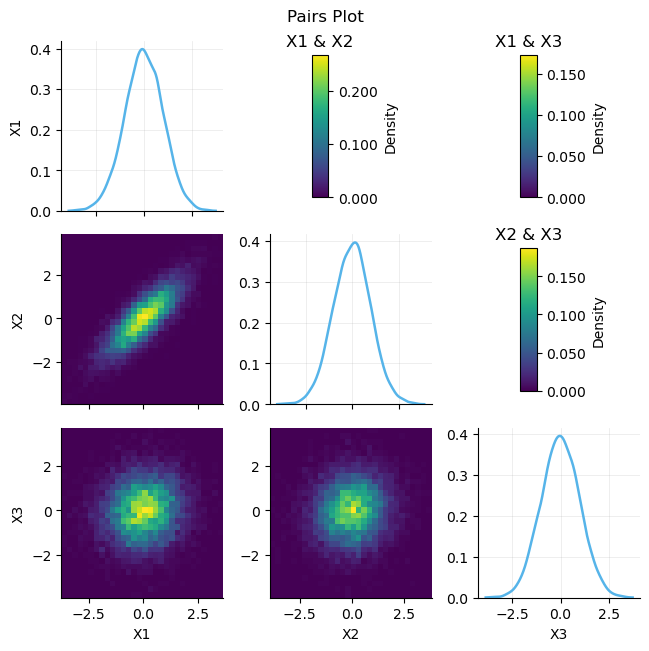

In [2]:
X = RV(MultivariateNormal(mean=[0, 0, 0],
                          cov=[[1.0, 0.8, 0.1],
                               [0.8, 1.0, 0.1],
                               [0.1, 0.1, 1.0]]))
sim = X.sim(10000)
sim.plot(pairs=True)

The `X1`-`X2` panel is a tight diagonal ridge (correlation 0.8) while the two panels
involving `X3` are round blobs (correlation 0.1) -- which is the relationship the matrix
exists to make visible at a glance.

Compare it with the exact distribution, drawn the same way:

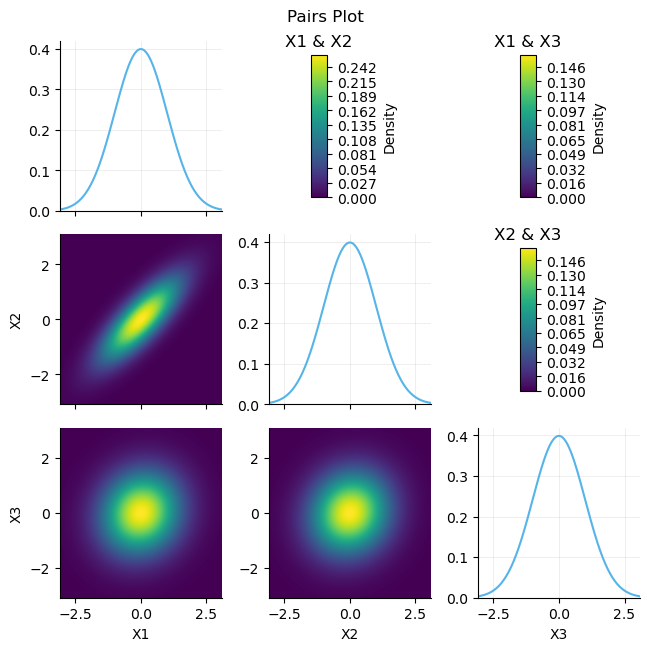

In [3]:
MultivariateNormal(mean=[0, 0, 0],
                   cov=[[1.0, 0.8, 0.1],
                        [0.8, 1.0, 0.1],
                        [0.1, 0.1, 1.0]]).plot(pairs=True)

## Discrete variables

When a variable takes only a handful of values, a density curve would smear a probability
mass function into a smooth curve it isn't -- so the diagonal switches to an **impulse**
plot, and the joint panels become **tile** plots, one cell per combination.

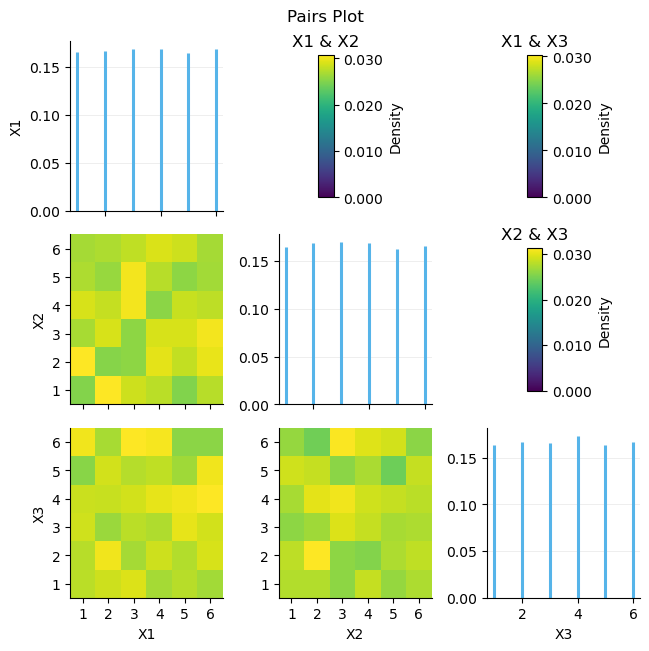

In [4]:
rolls = RV(BoxModel([1, 2, 3, 4, 5, 6], size=3))
rolls.sim(10000).plot(pairs=True)

Three independent dice, so every cell holds about the same share of the data and no panel
shows any structure -- exactly what independence should look like here.

## A mix of discrete and continuous

Each panel is chosen from the pair it shows, so a mixed pair gets a tile plot with the
continuous axis binned. Here a die roll decides which of three normal distributions a
measurement comes from.

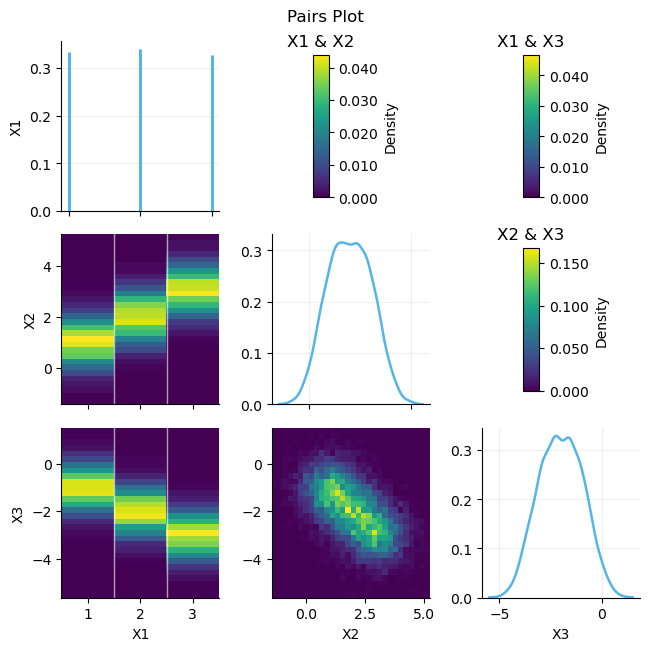

In [5]:
# A group label (1, 2 or 3), and two measurements whose centers depend on it.
def draw_one():
    group = BoxModel([1, 2, 3]).draw()
    return (group,
            Normal(mean=group, sd=0.7).draw(),
            Normal(mean=-group, sd=0.7).draw())

grouped = RV(ProbabilitySpace(draw_one))
grouped.sim(10000).plot(pairs=True)

The `X1`-`X2` panel shows the measurement shifting up as the group label rises, and the
`X1`-`X3` panel shows it shifting down -- read off the discrete axis one column of cells at
a time.

## Choosing which variables to show

A matrix grows quickly: six variables would need 21 panels. Pass `dims=` to pick the
variables worth looking at, numbered from 0.

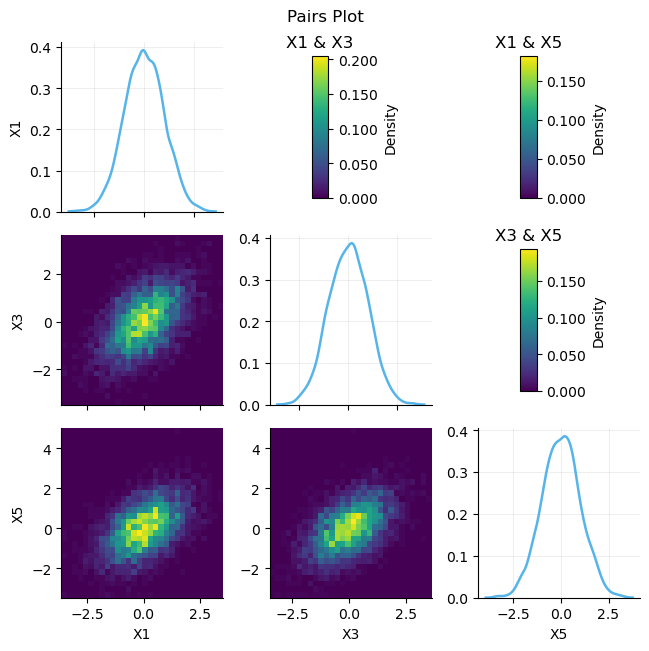

In [6]:
Y = RV(MultivariateNormal(mean=[0] * 5, cov=[[1.0 if i == j else 0.5 for j in range(5)]
                                             for i in range(5)]))
five = Y.sim(5000)
five.plot(pairs=True, dims=(0, 2, 4))  # the 1st, 3rd and 5th

## Notes

- Every panel in a column covers the same variable with the same number of bins, so the
  columns can be compared directly. Pass `bins=` to change that number for the whole matrix.
- The matrix fills the figure, so it cannot share one with another plot -- a second `.plot()`
  in the same cell raises an error rather than drawing on top of a panel.
- Panels show densities by default; `normalize=False` switches the whole matrix to raw
  counts.

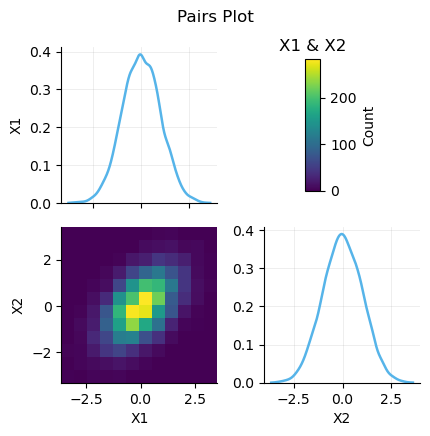

In [7]:
five.plot(pairs=True, dims=(0, 1), bins=12, normalize=False)